### Given a real 10 MS/s Mumbai OTA capture, can our production detector discover the stations by itself

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from iqwav.dsp import welch_psd
from iqwav.estimation import detect_occupied_bands

mumbai_path = Path(
    "../../data/external/mumbai-10s-10M-92.3-8-10-25.iq"
)

fs = 10_000_000
rf_center = 92.3e6

In [2]:
chunk_samples = 2_000_000       # 0.2 s
start_sample = 50_000_000       # somewhere near middle

with open(mumbai_path, "rb") as f:
    f.seek(start_sample * np.dtype(np.complex64).itemsize)
    iq = np.fromfile(
        f,
        dtype=np.complex64,
        count=chunk_samples
    )

print("Shape:", iq.shape)
print("Duration:", len(iq) / fs, "s")
print("Finite:", np.all(np.isfinite(iq)))

Shape: (2000000,)
Duration: 0.2 s
Finite: True


In [3]:
bands, noise_floor_db = detect_occupied_bands(
    iq,
    fs,
    nperseg=16384,
    threshold_db=6,
    min_bins=5
)

print("Noise floor:", noise_floor_db, "dB")
print("Detected bands:", len(bands))

for i, band in enumerate(bands, 1):
    print(
        i,
        "relative center =", band.center_hz / 1e6, "MHz",
        "| RF center =", (rf_center + band.center_hz) / 1e6, "MHz",
        "| BW =", band.bandwidth_hz / 1e3, "kHz",
        "| peak margin =", band.peak_above_noise_db, "dB"
    )

Noise floor: -118.662353515625 dB
Detected bands: 5
1 relative center = -1.18621826171875 MHz | RF center = 91.11378173828125 MHz | BW = 69.580078125 kHz | peak margin = 10.640342712402344 dB
2 relative center = -0.40191650390625 MHz | RF center = 91.89808349609375 MHz | BW = 161.1328125 kHz | peak margin = 23.34442901611328 dB
3 relative center = 0.40130615234375 MHz | RF center = 92.70130615234375 MHz | BW = 173.33984375 kHz | peak margin = 25.614791870117188 dB
4 relative center = 0.49591064453125 MHz | RF center = 92.79591064453125 MHz | BW = 3.662109375 kHz | peak margin = 7.723243713378906 dB
5 relative center = 1.181640625 MHz | RF center = 93.481640625 MHz | BW = 97.0458984375 kHz | peak margin = 27.925804138183594 dB


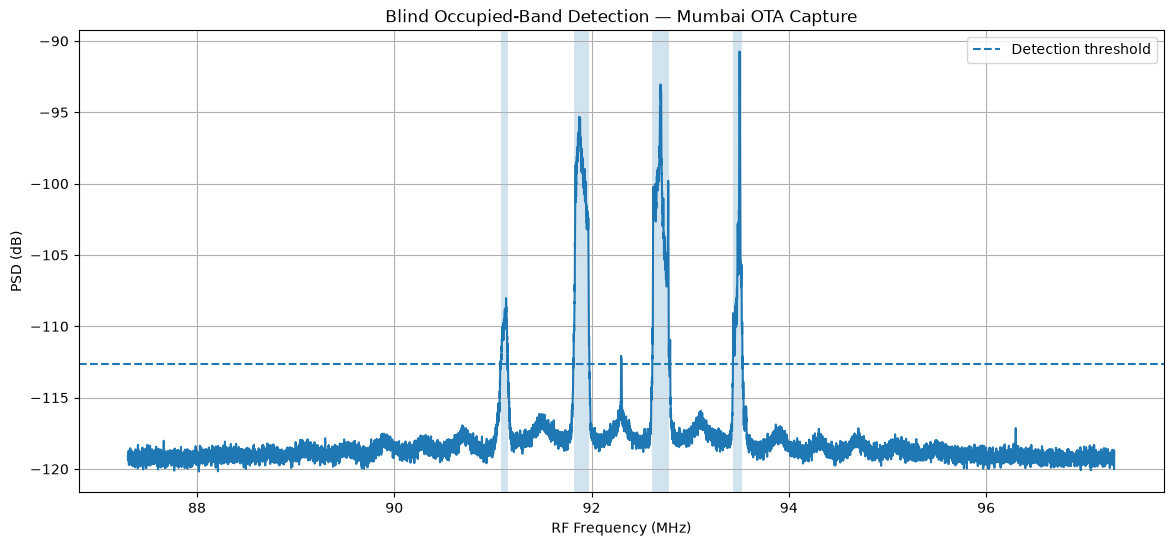

In [4]:
f_psd, p_psd = welch_psd(
    iq,
    fs,
    nperseg=16384
)

p_db = 10 * np.log10(p_psd)

plt.figure(figsize=(14, 6))

# Convert relative baseband frequency to absolute RF MHz
rf_axis_mhz = (rf_center + f_psd) / 1e6

plt.plot(rf_axis_mhz, p_db)

plt.axhline(
    noise_floor_db + 6,
    linestyle="--",
    label="Detection threshold"
)

for band in bands:
    plt.axvspan(
        (rf_center + band.lower_hz) / 1e6,
        (rf_center + band.upper_hz) / 1e6,
        alpha=0.2
    )

plt.xlabel("RF Frequency (MHz)")
plt.ylabel("PSD (dB)")
plt.title("Blind Occupied-Band Detection — Mumbai OTA Capture")
plt.grid()
plt.legend()
plt.show()